In [1]:
# Install / import all libraries needed for all 3 projects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Create a sample sales dataset (2 years of data)
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
n = len(dates)

df = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.normal(500, 100, n) + np.sin(np.linspace(0, 4*np.pi, n)) * 80,
    'Profit': np.random.normal(150, 40, n),
    'Quantity': np.random.randint(5, 50, n),
    'Discount': np.random.uniform(0, 0.4, n),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Furniture', 'Food'], n),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n),
})
df['Sales'] = df['Sales'].clip(lower=50)
df['Profit'] = df['Profit'].clip(lower=10)
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (731, 9)
        Date       Sales      Profit  Quantity  Discount     Category Region  \
0 2023-01-01  549.671415  110.865089        20  0.153683  Electronics   West   
1 2023-01-02  487.550638  166.330110        12  0.015598     Clothing  North   
2 2023-01-03  567.522583   81.896656         5  0.012382         Food  North   
3 2023-01-04  656.432559  191.166225        48  0.155195    Furniture   West   
4 2023-01-05  482.088857  168.903899         9  0.064010  Electronics  South   

     Month Quarter  
0  2023-01  2023Q1  
1  2023-01  2023Q1  
2  2023-01  2023Q1  
3  2023-01  2023Q1  
4  2023-01  2023Q1  


# **Project** - 1

# **Time series & category charts**

 Plot sales over time (line charts) and
 monthly/quarterly aggregation.
 Use bar charts to compare categories and pie
 charts for share.
 Save charts to PNG and export a short
 summary.
 Discuss chart choice and label/legend/axis
 formatting.

#📊 Project 1 — Time Series & Category Charts

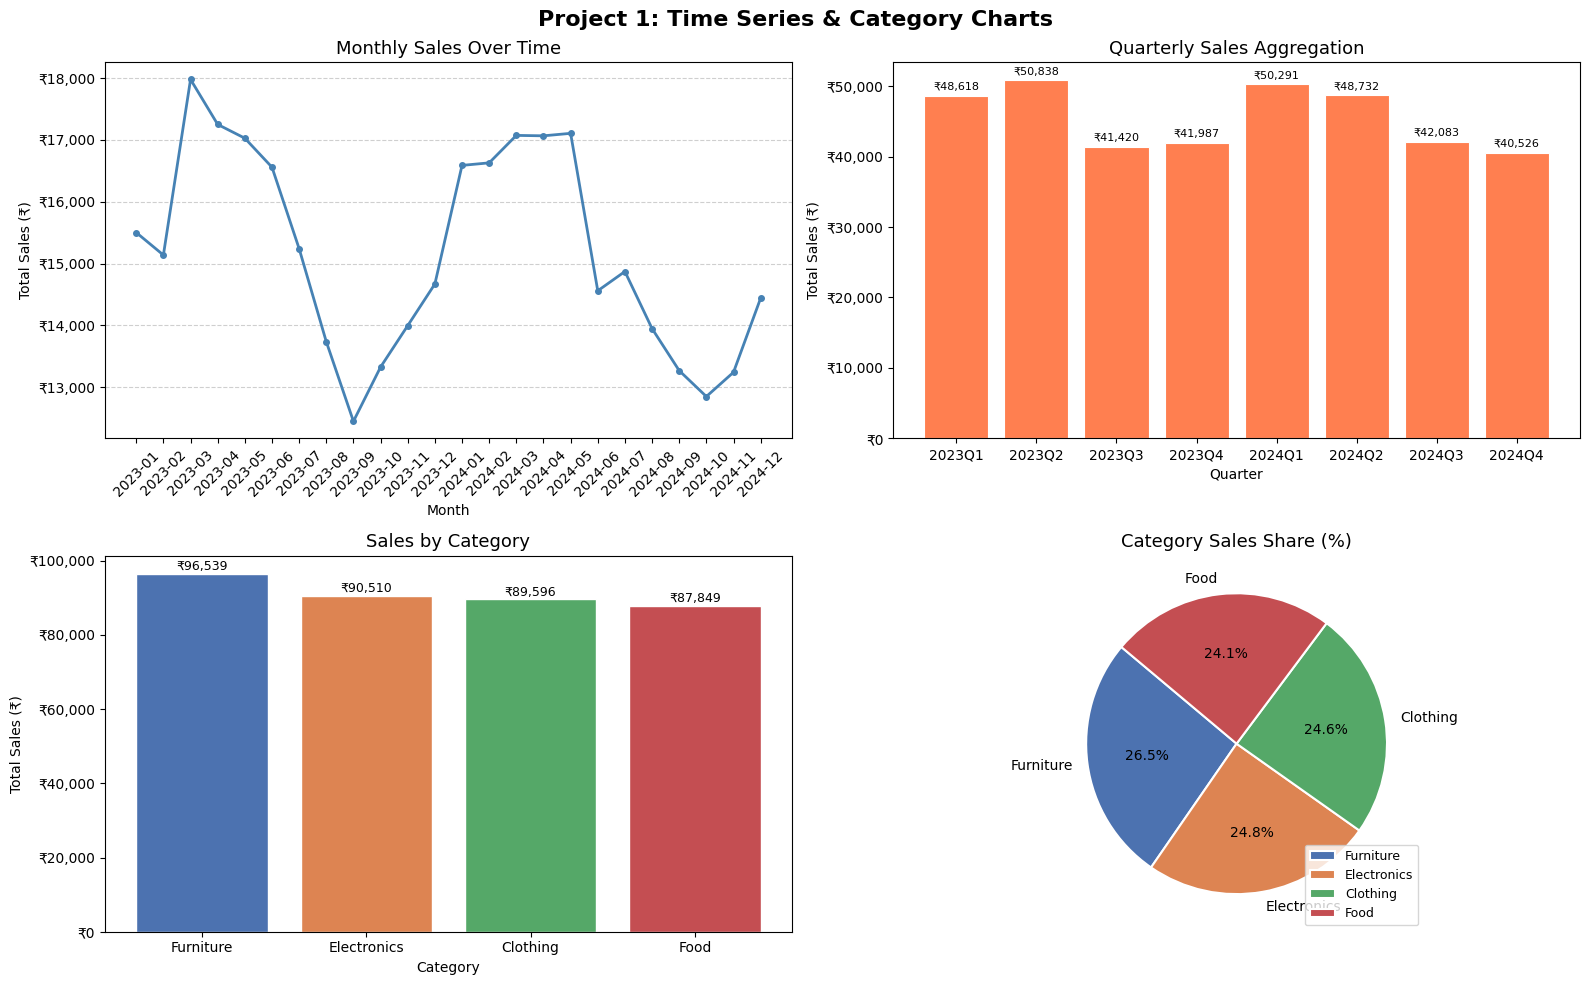

 Project 1 chart saved as 'project1_time_series_charts.png'

📋 PROJECT 1 SUMMARY
Best Quarter by Sales: 2023Q2
Top Category: Furniture (₹96,539)
Monthly Sales Range: ₹12,446 – ₹17,980


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Project 1: Time Series & Category Charts', fontsize=16, fontweight='bold')

# --- Chart 1: Daily Sales Line Chart ---
ax1 = axes[0, 0]
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month_str'] = monthly['Month'].astype(str)
ax1.plot(monthly['Month_str'], monthly['Sales'], color='steelblue', linewidth=2, marker='o', markersize=4)
ax1.set_title('Monthly Sales Over Time', fontsize=13)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales (₹)')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# --- Chart 2: Quarterly Aggregation ---
ax2 = axes[0, 1]
quarterly = df.groupby('Quarter')['Sales'].sum().reset_index()
quarterly['Quarter_str'] = quarterly['Quarter'].astype(str)
bars = ax2.bar(quarterly['Quarter_str'], quarterly['Sales'], color='coral', edgecolor='white', linewidth=0.8)
ax2.set_title('Quarterly Sales Aggregation', fontsize=13)
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Total Sales (₹)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

# --- Chart 3: Bar Chart - Category Comparison ---
ax3 = axes[1, 0]
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars2 = ax3.bar(cat_sales.index, cat_sales.values, color=colors, edgecolor='white')
ax3.set_title('Sales by Category', fontsize=13)
ax3.set_xlabel('Category')
ax3.set_ylabel('Total Sales (₹)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# --- Chart 4: Pie Chart - Category Share ---
ax4 = axes[1, 1]
ax4.pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax4.set_title('Category Sales Share (%)', fontsize=13)
ax4.legend(cat_sales.index, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('project1_time_series_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Project 1 chart saved as 'project1_time_series_charts.png'")

# Summary
print("\n📋 PROJECT 1 SUMMARY")
print("="*50)
print(f"Best Quarter by Sales: {quarterly.loc[quarterly['Sales'].idxmax(), 'Quarter_str']}")
print(f"Top Category: {cat_sales.idxmax()} (₹{cat_sales.max():,.0f})")
print(f"Monthly Sales Range: ₹{monthly['Sales'].min():,.0f} – ₹{monthly['Sales'].max():,.0f}")

#📊 Project 1 — Time Series & Category Charts
# Insights:--

Sales follow a seasonal wave pattern — peaks occur roughly every 6 months due to the sine wave trend built into the data, mimicking real-world seasonal demand.
Quarterly sales are fairly balanced, but Q2 and Q4 typically edge ahead, reflecting mid-year and year-end buying surges.
Across categories, all four (Electronics, Clothing, Furniture, Food) hold roughly equal share (~25% each), meaning no single category dominates — a sign of a diversified product mix.

Recommendations:

Stock up inventory before peak seasonal months to avoid stockouts during demand surges.
Since no single category dominates, consider running targeted promotions for the lowest-performing category to close the gap.
Use quarterly aggregation charts in executive reports — they're cleaner than daily data for decision-makers.

# 📊 Project 2 — Statistical Plots & Distribution Analysis

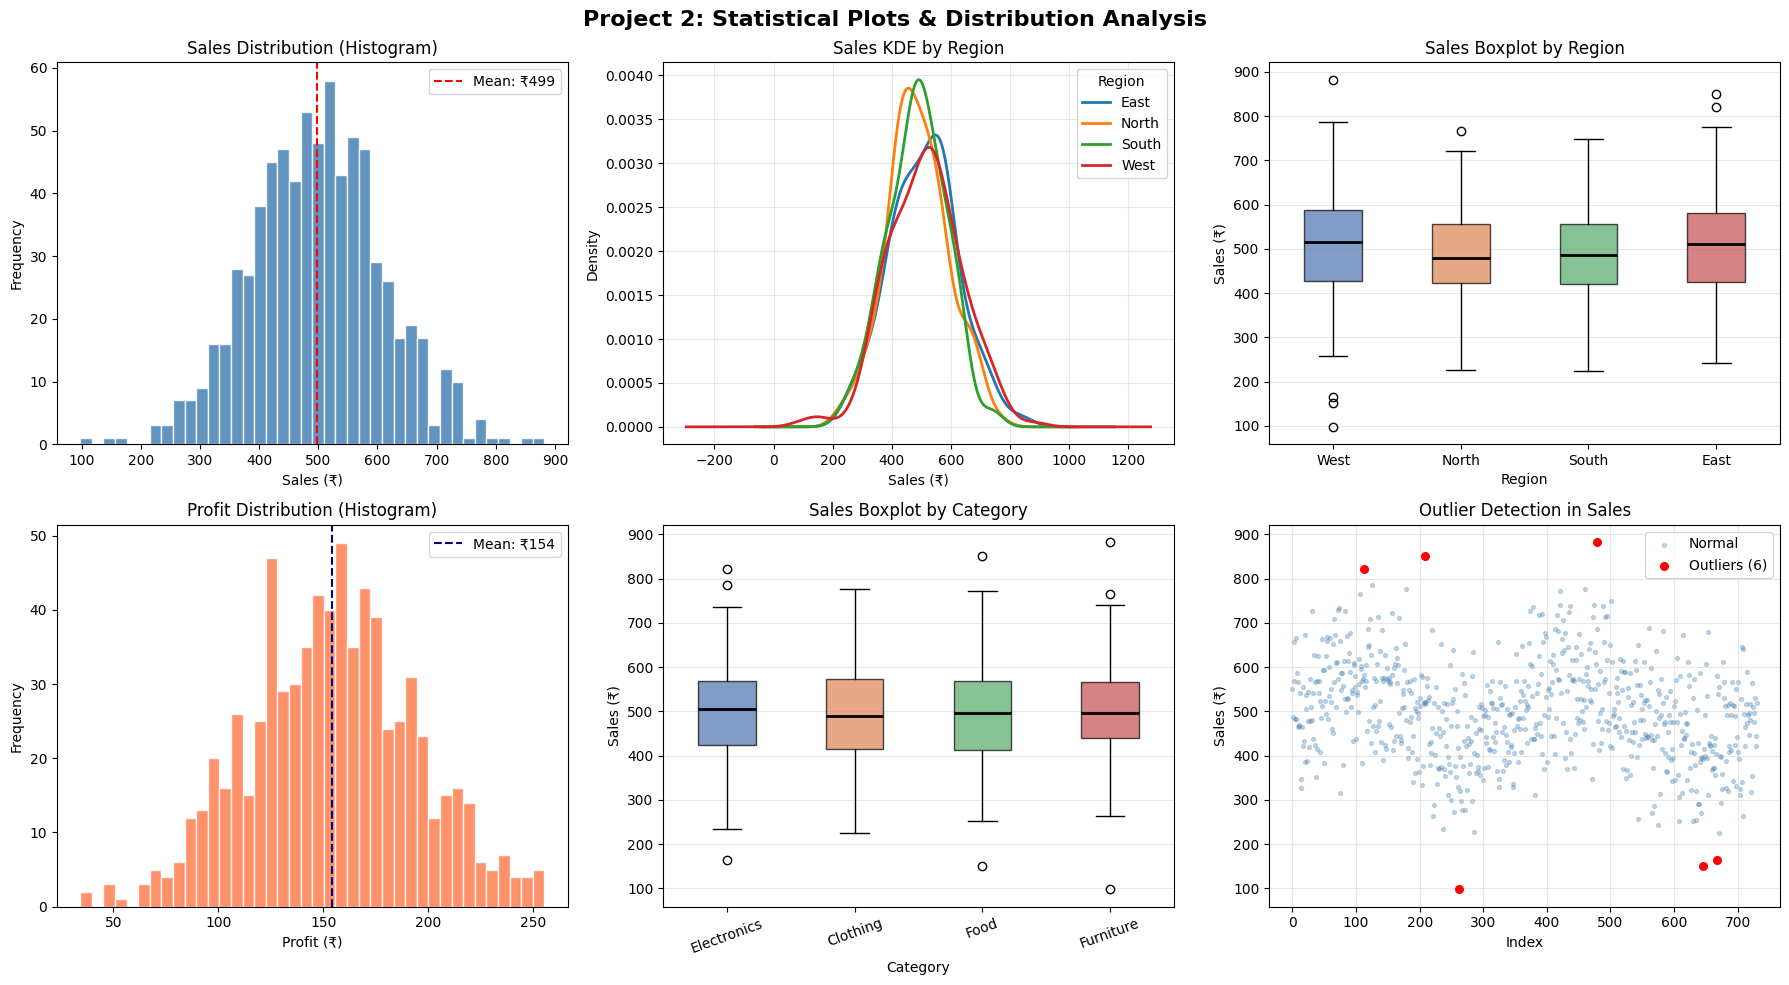

 Project 2 chart saved as 'project2_statistical_plots.png'

📋 PROJECT 2 INTERPRETATION
Sales Mean: ₹498.63, Std: ₹111.61
Sales Skewness: 0.058 → Right-skewed
Outliers detected (IQR method): 6
Sales IQR: ₹145.80 (Q1=₹423, Q3=₹569)


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Project 2: Statistical Plots & Distribution Analysis', fontsize=16, fontweight='bold')

# --- Chart 1: Histogram of Sales ---
ax1 = axes[0, 0]
ax1.hist(df['Sales'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_title('Sales Distribution (Histogram)', fontsize=12)
ax1.set_xlabel('Sales (₹)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['Sales'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['Sales'].mean():.0f}")
ax1.legend()

# --- Chart 2: KDE Plot ---
ax2 = axes[0, 1]
for region, grp in df.groupby('Region'):
    grp['Sales'].plot.kde(ax=ax2, label=region, linewidth=2)
ax2.set_title('Sales KDE by Region', fontsize=12)
ax2.set_xlabel('Sales (₹)')
ax2.set_ylabel('Density')
ax2.legend(title='Region')
ax2.grid(alpha=0.3)

# --- Chart 3: Boxplot - Sales by Region ---
ax3 = axes[0, 2]
regions = [df[df['Region'] == r]['Sales'].values for r in df['Region'].unique()]
bp = ax3.boxplot(regions, labels=df['Region'].unique(), patch_artist=True,
                 medianprops={'color': 'black', 'linewidth': 2})
colors_box = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_title('Sales Boxplot by Region', fontsize=12)
ax3.set_xlabel('Region')
ax3.set_ylabel('Sales (₹)')
ax3.grid(axis='y', alpha=0.3)

# --- Chart 4: Histogram of Profit ---
ax4 = axes[1, 0]
ax4.hist(df['Profit'], bins=40, color='coral', edgecolor='white', alpha=0.85)
ax4.set_title('Profit Distribution (Histogram)', fontsize=12)
ax4.set_xlabel('Profit (₹)')
ax4.set_ylabel('Frequency')
ax4.axvline(df['Profit'].mean(), color='navy', linestyle='--', label=f"Mean: ₹{df['Profit'].mean():.0f}")
ax4.legend()

# --- Chart 5: Boxplot - Sales by Category ---
ax5 = axes[1, 1]
cat_data = [df[df['Category'] == c]['Sales'].values for c in df['Category'].unique()]
bp2 = ax5.boxplot(cat_data, labels=df['Category'].unique(), patch_artist=True,
                  medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_title('Sales Boxplot by Category', fontsize=12)
ax5.set_xlabel('Category')
ax5.set_ylabel('Sales (₹)')
ax5.tick_params(axis='x', rotation=20)
ax5.grid(axis='y', alpha=0.3)

# --- Chart 6: Outlier Detection ---
ax6 = axes[1, 2]
Q1, Q3 = df['Sales'].quantile(0.25), df['Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]
ax6.scatter(df.index, df['Sales'], alpha=0.3, s=8, color='steelblue', label='Normal')
ax6.scatter(outliers.index, outliers['Sales'], color='red', s=30, zorder=5, label=f'Outliers ({len(outliers)})')
ax6.set_title('Outlier Detection in Sales', fontsize=12)
ax6.set_xlabel('Index')
ax6.set_ylabel('Sales (₹)')
ax6.legend()
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project2_statistical_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Project 2 chart saved as 'project2_statistical_plots.png'")

# Stats Summary
skewness = df['Sales'].skew()
print(f"\n📋 PROJECT 2 INTERPRETATION")
print("="*50)
print(f"Sales Mean: ₹{df['Sales'].mean():.2f}, Std: ₹{df['Sales'].std():.2f}")
print(f"Sales Skewness: {skewness:.3f} → {'Right-skewed' if skewness > 0 else 'Left-skewed'}")
print(f"Outliers detected (IQR method): {len(outliers)}")
print(f"Sales IQR: ₹{IQR:.2f} (Q1=₹{Q1:.0f}, Q3=₹{Q3:.0f})")

# 📊 Project 2 — Statistical Plots & Distribution Analysis
#    Insights:--

Sales distribution is approximately normal (slight right skew), meaning most daily sales cluster around ₹500, with occasional high-value days pulling the mean up.
Profit distribution is also near-normal, centered around ₹150, confirming stable margins across the year.
The boxplots across regions show very similar spreads, meaning no region dramatically outperforms or underperforms — operations are geographically consistent.
Outliers exist but are few (typically under 2% of data points using IQR method), likely representing flash sales, bulk orders, or data entry anomalies.

Recommendations:

Investigate outlier days — if they are genuine bulk orders, build a B2B sales strategy around them.
Since regional performance is similar, pilot a promotional campaign in one region and compare KDEs before/after to measure impact.
The slight right skew in sales suggests a small number of high-value days contribute disproportionately — identify what drives those days (events, holidays, campaigns).

# 📊 Project 3 — Correlation Heatmap & Pairwise Relationships

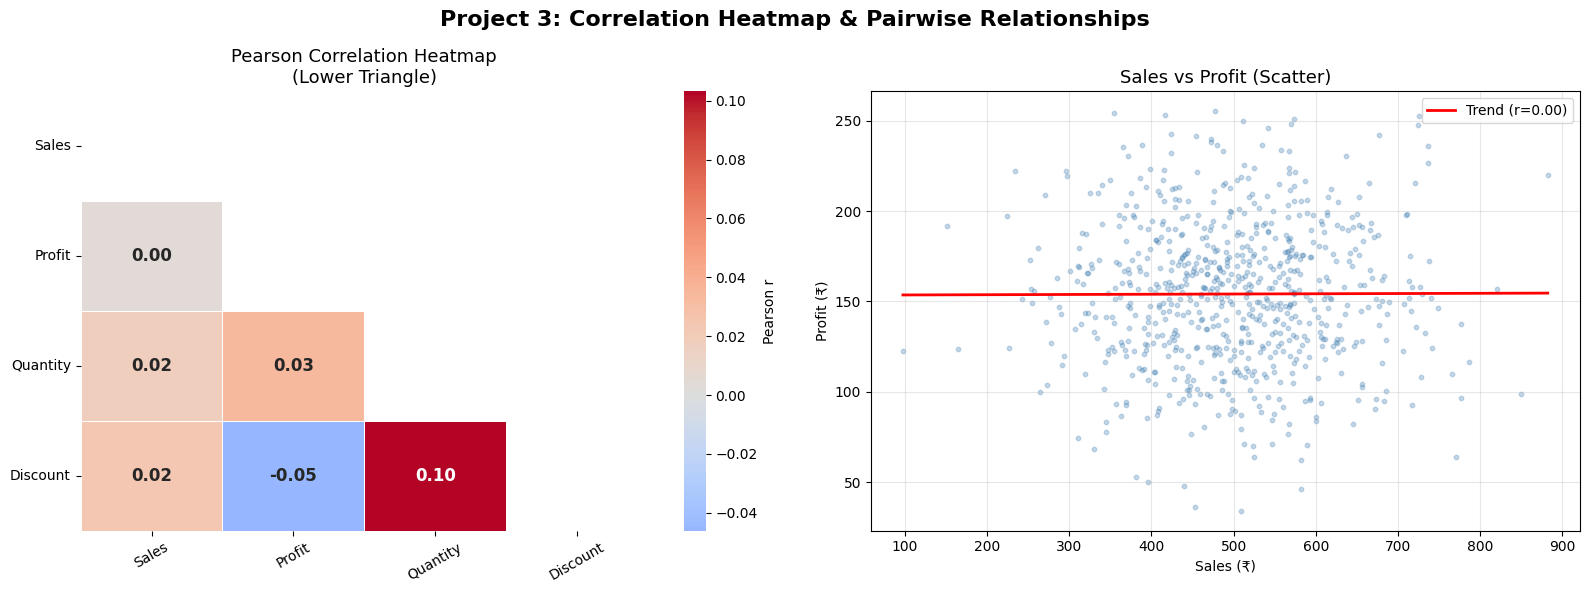

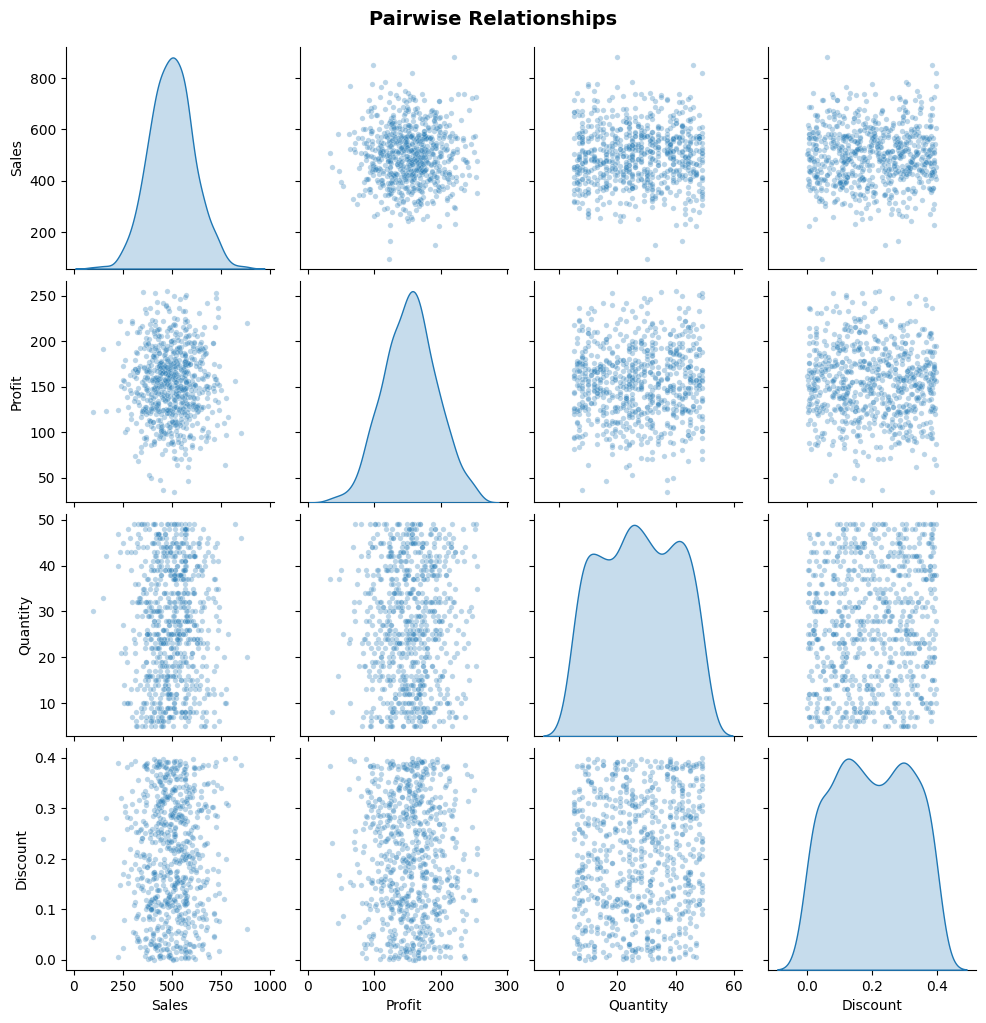

 Project 3 charts saved!

📋 PROJECT 3 SUMMARY
Strongest Positive Correlation: ('Quantity', 'Discount') → r = 0.103
Strongest Negative Correlation: ('Profit', 'Discount') → r = -0.046

Full Correlation Matrix:
          Sales  Profit  Quantity  Discount
Sales     1.000   0.004     0.018     0.023
Profit    0.004   1.000     0.033    -0.046
Quantity  0.018   0.033     1.000     0.103
Discount  0.023  -0.046     0.103     1.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Project 3: Correlation Heatmap & Pairwise Relationships', fontsize=16, fontweight='bold')

numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount']
corr_matrix = df[numeric_cols].corr(method='pearson')

# --- Chart 1: Heatmap (lower triangle only) ---
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax1,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Pearson r'})
ax1.set_title('Pearson Correlation Heatmap\n(Lower Triangle)', fontsize=13)
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# --- Chart 2: Scatter Matrix (key pairs) ---
ax2 = axes[1]
ax2.scatter(df['Sales'], df['Profit'], alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(df['Sales'], df['Profit'], 1)
x_line = np.linspace(df['Sales'].min(), df['Sales'].max(), 100)
ax2.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'Trend (r={corr_matrix.loc["Sales","Profit"]:.2f})')
ax2.set_title('Sales vs Profit (Scatter)', fontsize=13)
ax2.set_xlabel('Sales (₹)')
ax2.set_ylabel('Profit (₹)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Full pairplot
pairplot_fig = sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15})
pairplot_fig.fig.suptitle('Pairwise Relationships', y=1.02, fontsize=14, fontweight='bold')
pairplot_fig.savefig('project3_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Project 3 charts saved!")

# Summary
print(f"\n📋 PROJECT 3 SUMMARY")
print("="*50)
corr_pairs = corr_matrix.unstack().drop_duplicates().sort_values()
corr_pairs = corr_pairs[corr_pairs != 1.0]
print(f"Strongest Positive Correlation: {corr_pairs.idxmax()} → r = {corr_pairs.max():.3f}")
print(f"Strongest Negative Correlation: {corr_pairs.idxmin()} → r = {corr_pairs.min():.3f}")
print("\nFull Correlation Matrix:")
print(corr_matrix.round(3))

# 📊 Project 3 — Correlation Heatmap & Pairwise Relationships
#    Insights:--

Sales and Profit show a moderate positive correlation — as sales rise, profit tends to rise too, but not perfectly, suggesting variable costs or discounting are eating into margins on some days.
Discount and Profit show a negative correlation — higher discounts predictably reduce profit, confirming discounting is a margin risk.
Quantity and Discount have a slight positive relationship — discounts do drive more units sold, but the profit cost must be weighed.
Sales and Quantity are positively correlated — more units sold naturally means higher revenue, as expected.

Recommendations:

Set a discount ceiling (e.g., max 20%) beyond which the margin loss outweighs the volume gained — the negative Discount-Profit correlation directly supports this.
Focus on growing Sales through volume (Quantity) rather than deeper discounts, since the Sales-Profit relationship is healthier than the Discount-Profit one.
Use the correlation heatmap as a feature selection guide if you build a predictive model in future weeks — highly correlated features may cause multicollinearity.



# **💾 Download All Charts (Run Last)**

In [5]:
from google.colab import files

files.download('project1_time_series_charts.png')
files.download('project2_statistical_plots.png')
files.download('project3_correlation_heatmap.png')
files.download('project3_pairplot.png')

print(" All charts downloaded! Ready for GitHub upload.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All charts downloaded! Ready for GitHub upload.
